In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


Predicting customer churn and translating behavioral patterns into retention insights

In [ ]:
import pandas as pd
df=pd.read_csv("Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


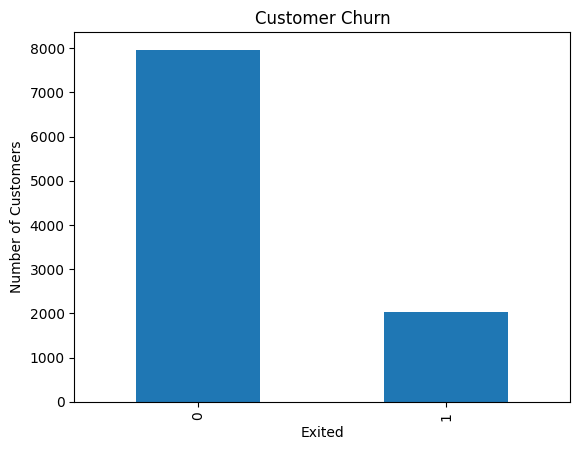

In [ ]:
import matplotlib.pyplot as plt

df['Exited'].value_counts().plot(kind='bar')
plt.title("Customer Churn")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()

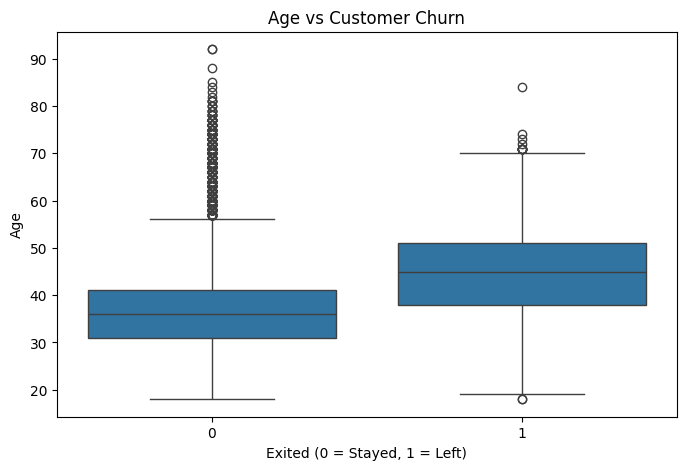

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Age', data=df)

plt.title("Age vs Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Left)")
plt.ylabel("Age")
plt.show()


In [ ]:
df.groupby('Tenure')['Exited'].mean()

,Exited
Tenure,
0,0.230024
1,0.224155
2,0.191794
3,0.211100
4,0.205258
5,0.206522
6,0.202689
7,0.172179
8,0.192195


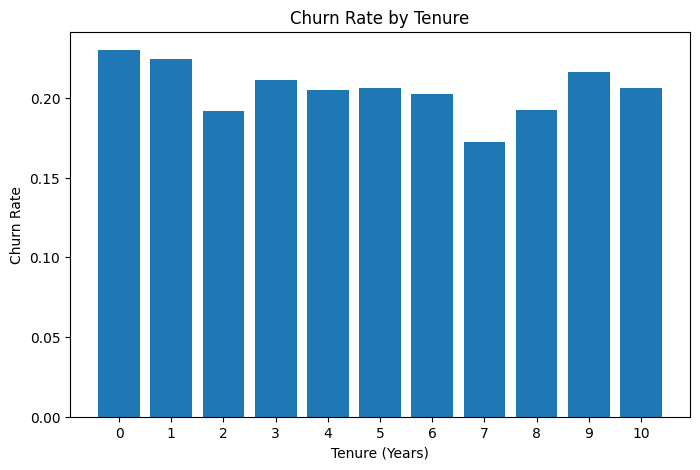

In [ ]:
import matplotlib.pyplot as plt

tenure_churn = df.groupby('Tenure')['Exited'].mean()

plt.figure(figsize=(8,5))
plt.bar(tenure_churn.index, tenure_churn.values)

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate")
plt.xticks(tenure_churn.index)
plt.show()

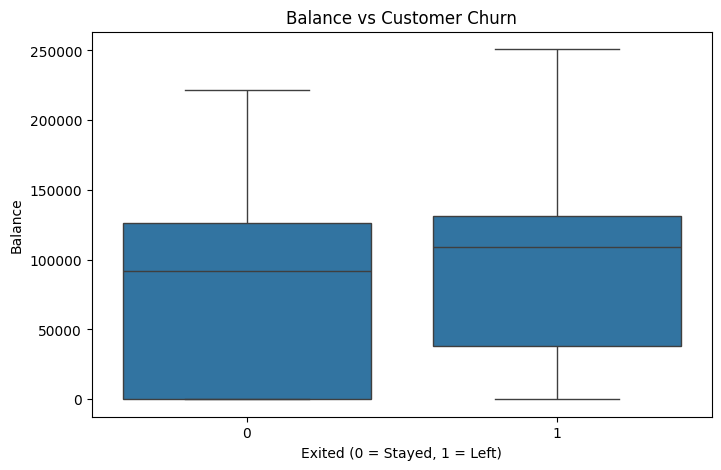

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Balance', data=df)

plt.title("Balance vs Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Left)")
plt.ylabel("Balance")
plt.show()

In [ ]:
pd.crosstab(df['IsActiveMember'], df['Exited'])

Exited,0,1
IsActiveMember,,
0,3547,1302
1,4416,735


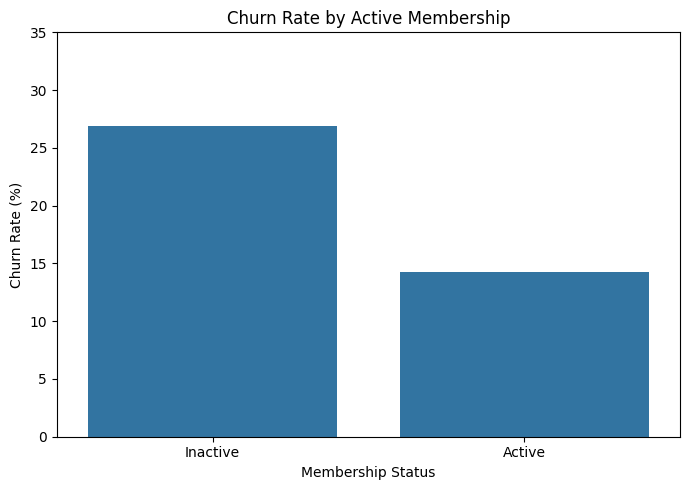

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

active_churn = (
    df.groupby('IsActiveMember')['Exited']
      .mean()
      .reset_index()
)

active_churn['IsActiveMember'] = active_churn['IsActiveMember'].map({
    0: 'Inactive',
    1: 'Active'
})

active_churn['Exited'] = active_churn['Exited'] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=active_churn,
    x='IsActiveMember',
    y='Exited'
)

plt.title('Churn Rate by Active Membership')
plt.xlabel('Membership Status')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 35)

plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab(df['IsActiveMember'],
            df['Exited'],
            normalize='index') * 100

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


In [ ]:
df.groupby('NumOfProducts')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
NumOfProducts,,,,,,,,
1,5084.0,39.673092,10.659566,18.0,32.0,38.0,45.00,92.0
2,4590.0,37.753595,10.145663,18.0,31.0,36.0,42.00,92.0
3,266.0,43.195489,10.422008,21.0,36.0,42.0,50.00,77.0
4,60.0,45.683333,8.619040,29.0,40.0,45.0,50.25,68.0


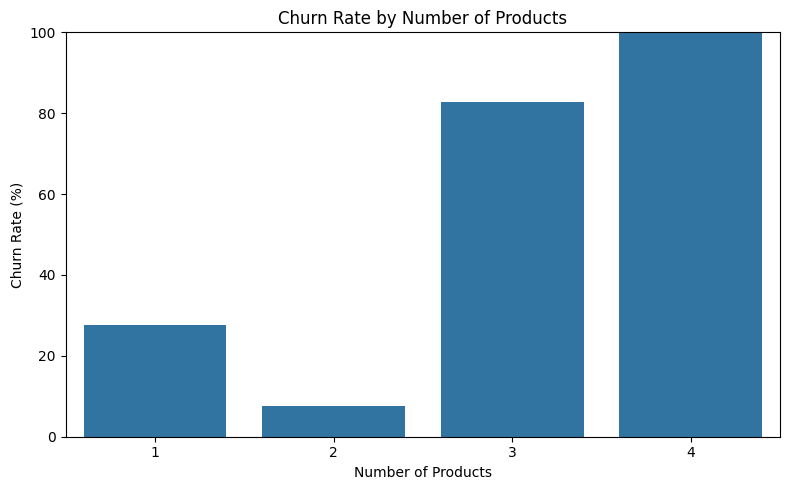

In [ ]:
product_churn = (
    df.groupby('NumOfProducts')['Exited']
      .mean()
      .reset_index()
)

product_churn['Exited'] = product_churn['Exited'] * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_churn,
    x='NumOfProducts',
    y='Exited'
)

plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab(df['NumOfProducts'], df['IsActiveMember'])

IsActiveMember,0,1
NumOfProducts,,
1,2521,2563
2,2144,2446
3,153,113
4,31,29


In [ ]:
df.groupby('NumOfProducts')['Exited'].mean()

,Exited
NumOfProducts,
1,0.277144
2,0.075817
3,0.827068
4,1.000000


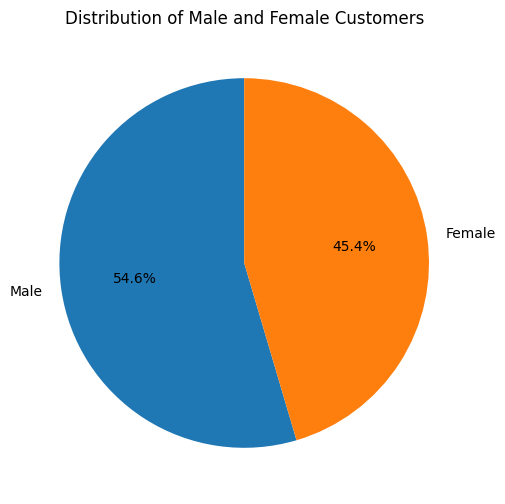

In [ ]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Male and Female Customers")
plt.show()

In [ ]:
pd.crosstab(df['Gender'], df['Exited'], normalize='index') * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


In [ ]:
country_churn = df.groupby('Geography')['Exited'].mean() * 100
country_churn

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


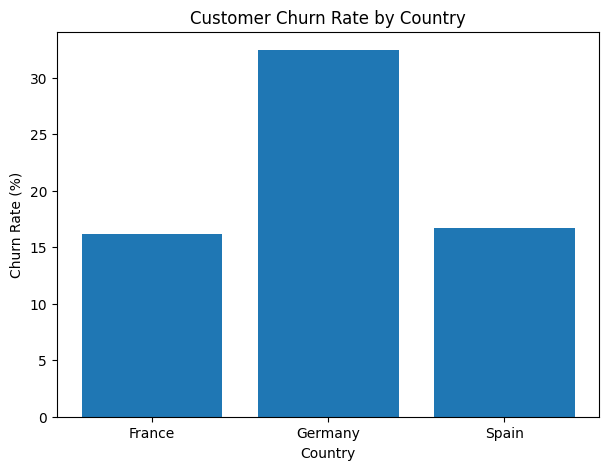

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(country_churn.index, country_churn.values)

plt.title("Customer Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")
plt.show()

In [ ]:
df.groupby('Geography')['Age'].mean()

,Age
Geography,
France,38.511767
Germany,39.771622
Spain,38.890997


In [ ]:
Balance_of_country=df.groupby('Geography')['Balance'].mean()
Balance_of_country.sort_values(ascending=False)

,Balance
Geography,
Germany,119730.116134
France,62092.636516
Spain,61818.147763


In [ ]:
df.groupby(['Geography', 'Gender', 'IsActiveMember'])[
    ['NumOfProducts', 'Balance', 'HasCrCard', 'Exited']
].mean()

NumOfProducts        Balance  HasCrCard  \
Geography Gender IsActiveMember                                            
France    Female 0                    1.546861   61034.923294   0.698817   
                 1                    1.548193   59649.033158   0.697074   
          Male   0                    1.493202   65479.504917   0.716767   
                 1                    1.539538   61755.113891   0.710987   
Germany   Female 0                    1.488959  118710.993076   0.725552   
                 1                    1.536673  119639.299445   0.685152   
          Male   0                    1.500797  120473.016523   0.730463   
                 1                    1.551524  120065.518171   0.711176   
Spain     Female 0                    1.604563   58247.543175   0.716730   
                 1                    1.543517   61370.534742   0.699822   
          Male   0                    1.543036   60743.019593   0.682316   
                 1                    1.487316   65579.364112   0.686248   

                                   Exited  
Geography Gender IsActiveMember            
France    Female 0               0.262056  
                 1               0.148021  
          Male   0               0.169184  
                 1               0.088174  
Germany   Female 0               0.446372  
                 1               0.295170  
          Male   0               0.374801  
                 1               0.190131  
Spain     Female 0               0.292776  
                 1               0.136767  
          Male   0               0.184664  
                 1               0.085447

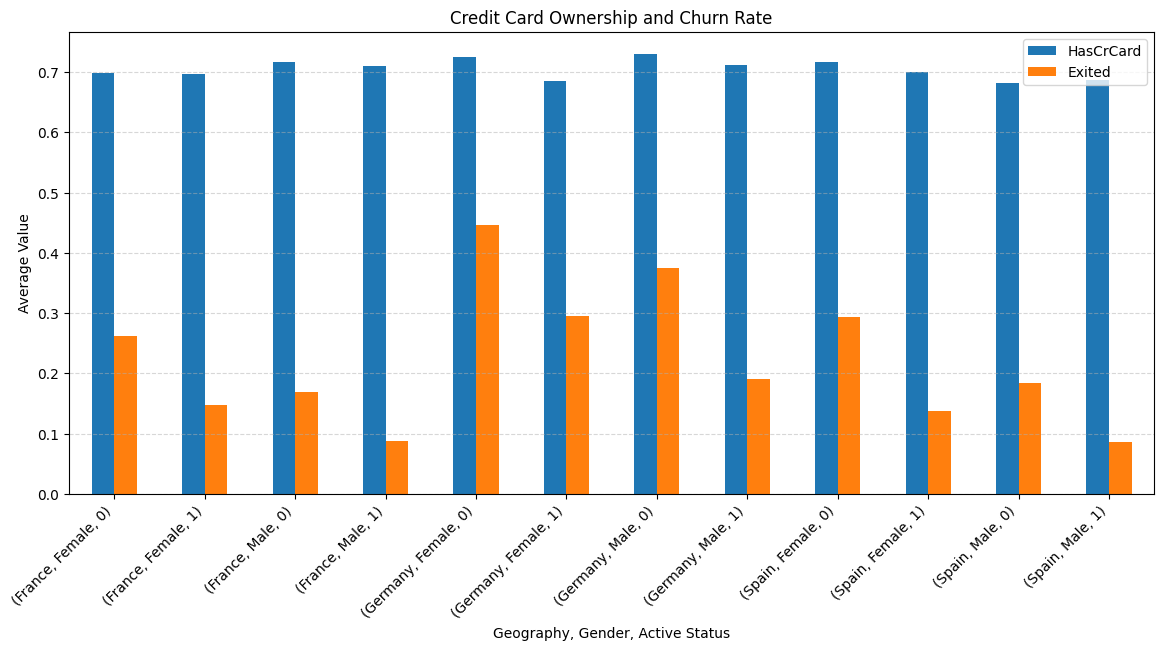

In [ ]:
import matplotlib.pyplot as plt

result = df.groupby(
    ['Geography', 'Gender', 'IsActiveMember']
)[['HasCrCard', 'Exited']].mean()

result.plot(kind='bar', figsize=(14,6))
plt.xticks(rotation=45, ha='right')
plt.title("Credit Card Ownership and Churn Rate")
plt.xlabel("Geography, Gender, Active Status")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

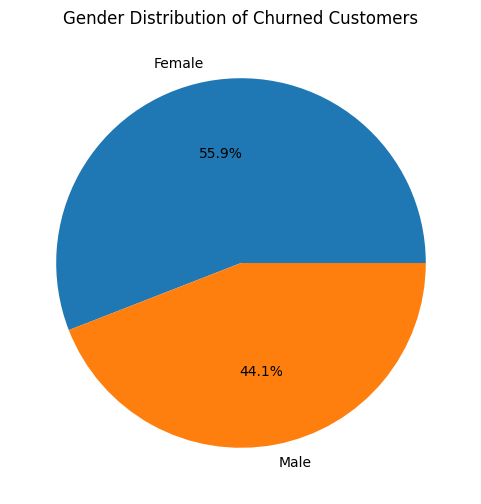

In [ ]:
churned = df[df['Exited'] == 1]

churned['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Gender Distribution of Churned Customers")
plt.ylabel("")
plt.show()

# Data Preprocessing

In [ ]:
df=df.drop(["RowNumber","CustomerId","Surname"],axis=1)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [ ]:
X=df.drop(["Exited"],axis=1)
y=df["Exited"]
#

In [ ]:
X.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58


In [ ]:
y.head(5)

,Exited
0,1
1,0
2,1
3,0
4,0


In [ ]:
X['Gender'] = X['Gender'].map({
    'Female': 0,
    'Male': 1
})

In [ ]:
X = pd.get_dummies(X, columns=['Geography'], drop_first=True) #one hot encoding

In [ ]:
X.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain'],
      dtype='object')

In [ ]:
# train_test_split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 11)
X_test : (2000, 11)
y_train: (8000,)
y_test : (2000,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42) #create model



In [ ]:
dt.fit(X_train,y_train) #train model

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred=dt.predict(X_test) #predict model

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy of the model is:",accuracy*100)

Accuracy of the model is: 78.45


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[1371  236]
 [ 195  198]]


In [ ]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1607
           1       0.46      0.50      0.48       393

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.79      0.78      0.79      2000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier( class_weight="balanced",

    random_state=42
)

In [ ]:
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_rd=rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred_rd)
print("Accuracy of the model is:",accuracy*100)

Accuracy of the model is: 86.6


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred_rd)
print(cm)

[[1553   54]
 [ 214  179]]


In [ ]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_pred_rd)
print("Classification report of random forest is:",cr)

Classification report of random forest is:               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
2                 Age    0.251775
4             Balance    0.141257
8     EstimatedSalary    0.138093
0         CreditScore    0.134321
5       NumOfProducts    0.133405
3              Tenure    0.079396
7      IsActiveMember    0.038046
9   Geography_Germany    0.028924
1              Gender    0.021314
6           HasCrCard    0.018623
10    Geography_Spain    0.014846


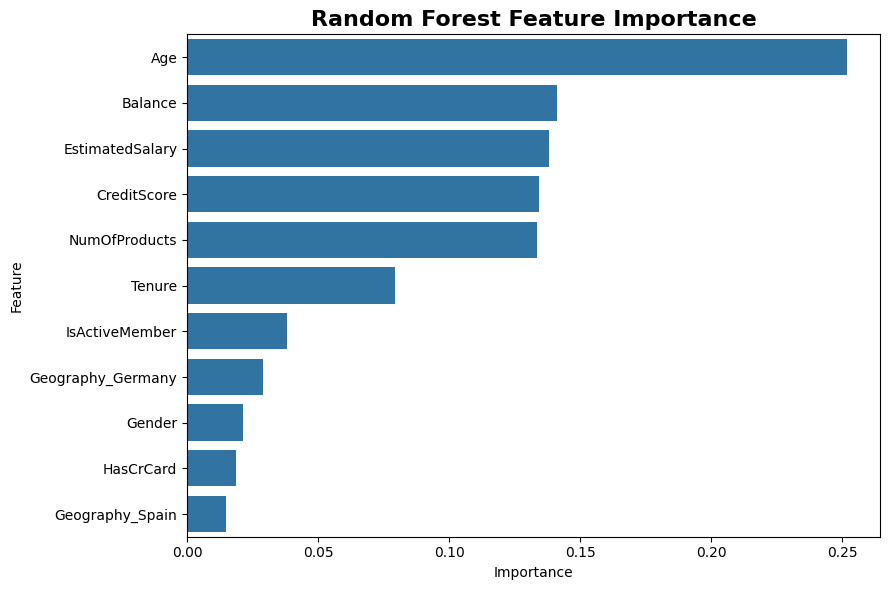

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create feature-importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Plot
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance", fontsize=16, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

# Save for GitHub
plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
y_prob = rf.predict_proba(X_test)[:, 1]

In [ ]:
y_prob

array([0.02, 0.04, 0.15, ..., 0.82, 0.09, 0.49])

In [ ]:
threshold = 0.30
y_pred = (y_prob >= threshold).astype(int)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1607
           1       0.57      0.66      0.62       393

    accuracy                           0.84      2000
   macro avg       0.74      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



In [ ]:
import pandas as pd

new_customers = pd.DataFrame({
    'CreditScore': [780, 580, 690],
    'Gender': [1, 0, 1],                 # 1 = Male, 0 = Female (adjust if your encoding is different)
    'Age': [35, 52, 41],
    'Tenure': [7, 2, 5],
    'Balance': [0, 145000, 85000],
    'NumOfProducts': [2, 1, 2],
    'HasCrCard': [1, 1, 0],
    'IsActiveMember': [1, 0, 1],
    'EstimatedSalary': [95000, 65000, 120000],
    'Geography_Germany': [0, 1, 0],
    'Geography_Spain': [0, 0, 1]
})

print(new_customers)

   CreditScore  Gender  Age  Tenure  Balance  NumOfProducts  HasCrCard  \
0          780       1   35       7        0              2          1   
1          580       0   52       2   145000              1          1   
2          690       1   41       5    85000              2          0   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  
0               1            95000                  0                0  
1               0            65000                  1                0  
2               1           120000                  0                1  


In [ ]:
predictions=rf.predict(new_customers)
print(predictions)

[0 1 0]


In [ ]:
prob = rf.predict_proba(new_customers)
print(prob)

[[0.96 0.04]
 [0.09 0.91]
 [0.9  0.1 ]]


In [ ]:
prob = rf.predict_proba(new_customers)[:, 1]

pred = (prob >= 0.30).astype(int)

print(prob)
print(pred)

[0.04 0.91 0.1 ]
[0 1 0]
